In [1]:
# Install required packages (run once)
!pip install scikit-learn scipy numpy pandas matplotlib seaborn --quiet
!pip install sktime --quiet  # For MiniRocket


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 9.0 MB/s eta 0:00:00


In [2]:
import os, glob, json, warnings
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, butter, filtfilt
from scipy.interpolate import interp1d
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("All imports successful")

All imports successful


In [3]:
# ── Configuration — adjust paths to match your Google Drive layout ──
from google.colab import drive
drive.mount('/content/drive')

AVDOS_CSV   = '/content/drive/MyDrive/Thesiswork/AVODS/Dataset_AVDOSVR_postprocessed.csv'
CEAP_PHYSIO = '/content/drive/MyDrive/Thesiswork/CEAP/CEAP-360VR-Dataset-master/CEAP-360VR/5_PhysioData/Frame'
CEAP_ANNOT  = '/content/drive/MyDrive/Thesiswork/CEAP/CEAP-360VR-Dataset-master/CEAP-360VR/3_AnnotationData/Frame'
SAVE_DIR    = '/content/drive/MyDrive/Thesiswork/processed_v2'
os.makedirs(SAVE_DIR, exist_ok=True)

# Signal parameters
AVDOS_FS   = 50          # AVDOS PPG sampling rate (Hz)
CEAP_FS    = 30          # CEAP BVP frame-synchronized rate (Hz)
WIN_SEC    = 10          # Window length in seconds
OVERLAP    = 0.5         # 50 % overlap → doubles the number of samples

AVDOS_WIN  = int(WIN_SEC * AVDOS_FS)   # 500 samples
CEAP_WIN   = int(WIN_SEC * CEAP_FS)    # 300 samples

print(f"AVDOS window: {AVDOS_WIN} samples  ({WIN_SEC}s @ {AVDOS_FS} Hz)")
print(f"CEAP  window: {CEAP_WIN}  samples  ({WIN_SEC}s @ {CEAP_FS} Hz)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AVDOS window: 500 samples  (10s @ 50 Hz)
CEAP  window: 300  samples  (10s @ 30 Hz)


In [4]:
# ── Signal Processing Utilities ──────────────────────────────────────

def bandpass_filter(signal, fs, low=0.5, high=4.0, order=3):
    """
    Zero-phase Butterworth bandpass filter.
    0.5–4 Hz covers 30–240 BPM — the full physiological cardiac range.
    filtfilt applies the filter forward and backward, so phase shift = 0.
    """
    nyq  = fs / 2.0
    b, a = butter(order, [low / nyq, min(high / nyq, 0.99)], btype='band')
    return filtfilt(b, a, signal.astype(float))


def get_ibi(ppg_window, fs):
    """
    Detect systolic peaks → compute inter-beat intervals (IBI) in ms.

    Steps:
      1. Z-score normalise so find_peaks threshold is scale-independent.
      2. Enforce 0.4 s minimum peak spacing (= 150 BPM max).
      3. Discard IBIs outside 333–2000 ms (30–180 BPM).

    Returns: ibi_ms array or None when fewer than 3 valid beats found.
    """
    sig = ppg_window.copy()
    std = np.std(sig)
    if std == 0:
        return None
    sig = (sig - np.mean(sig)) / std

    peaks, _ = find_peaks(sig, distance=int(0.4 * fs),
                          prominence=0.3, height=0.0)
    if len(peaks) < 3:
        return None

    ibi = np.diff(peaks) / fs * 1000.0          # Convert samples → ms
    ibi = ibi[(ibi >= 333) & (ibi <= 2000)]     # Physiology filter
    return ibi if len(ibi) >= 3 else None


def hrv_features(ibi_ms):
    """
    Extract 7 time-domain HRV features from an IBI sequence.

    These are the gold-standard emotion recognition features:
      mean_hr   — beats per minute
      mean_ibi  — average beat spacing (ms)
      sdnn      — std of all IBIs; reflects overall ANS variability
      rmssd     — root-mean-square of successive diffs; parasympathetic marker
      pnn50     — % of consecutive diffs > 50 ms; parasympathetic marker
      cv_ibi    — coefficient of variation (sdnn / mean_ibi); normalised spread
      ibi_range — max − min IBI; rough amplitude measure
    """
    if ibi_ms is None or len(ibi_ms) < 4:
        return None

    diff = np.diff(ibi_ms)
    mean = np.mean(ibi_ms)

    return [
        60000.0 / mean,                                  # mean_hr
        mean,                                            # mean_ibi
        np.std(ibi_ms, ddof=1),                         # sdnn
        np.sqrt(np.mean(diff ** 2)),                     # rmssd
        np.sum(np.abs(diff) > 50) / len(diff),          # pnn50
        np.std(ibi_ms, ddof=1) / mean,                  # cv_ibi
        float(np.max(ibi_ms) - np.min(ibi_ms)),         # ibi_range
    ]


FEAT_NAMES = ['mean_hr', 'mean_ibi', 'sdnn', 'rmssd', 'pnn50', 'cv_ibi', 'ibi_range']


def make_windows(signal, win_size, overlap=0.5):
    """Yield (start_idx, window) tuples with configurable overlap."""
    step = int(win_size * (1 - overlap))
    for s in range(0, len(signal) - win_size + 1, step):
        yield s, signal[s : s + win_size]


print(f"Utilities ready  |  HRV features: {FEAT_NAMES}")


Utilities ready  |  HRV features: ['mean_hr', 'mean_ibi', 'sdnn', 'rmssd', 'pnn50', 'cv_ibi', 'ibi_range']


In [ ]:
# ── AVDOS Data Pipeline ───────────────────────────────────────────────
# Signal source : Ppg/Raw.ppg  (50 Hz)
# Labels        : Arousal, Valence per (Participant × VideoId)
#                 binarised using each subject's own mean → removes baseline

print("Processing AVDOS ...")

X_a, Ya_a, Yv_a, subj_a, ppg_a = [], [], [], [], []
skip, total = 0, 0

df = pd.read_csv(AVDOS_CSV)
print(f"  Loaded {len(df):,} rows, {df['Participant'].nunique()} participants")

# Drop rows with missing essentials
df = df.dropna(subset=['Participant', 'VideoId', 'Ppg/Raw.ppg', 'Arousal', 'Valence'])
df = df[df['VideoId'] > 0]
print(f"  After cleaning: {len(df):,} rows")

# Per-subject arousal / valence mean as binarisation threshold
thr = df.groupby('Participant')[['Arousal', 'Valence']].mean()

for (pid, vid), grp in df.groupby(['Participant', 'VideoId']):
    grp = grp.sort_index()
    raw = grp['Ppg/Raw.ppg'].ffill().values
    if len(raw) < AVDOS_WIN:
        continue

    filt  = bandpass_filter(raw, AVDOS_FS)   # Filter once per segment

    la = int(grp['Arousal'].iloc[0] > thr.loc[pid, 'Arousal'])
    lv = int(grp['Valence'].iloc[0] > thr.loc[pid, 'Valence'])

    for _, win in make_windows(filt, AVDOS_WIN, OVERLAP):
        total += 1
        ibi  = get_ibi(win, AVDOS_FS)
        feat = hrv_features(ibi)
        if feat is None:
            skip += 1
            continue
        X_a.append(feat);   Ya_a.append(la)
        Yv_a.append(lv);    subj_a.append(pid)
        ppg_a.append(win.copy())

print(f"  Windows: {total} total, {skip} skipped ({100*skip/max(total,1):.1f}%), "
      f"{len(X_a)} valid")

AVDOS_X    = np.array(X_a,    dtype=np.float32)
AVDOS_Ya   = np.array(Ya_a,   dtype=np.int8)
AVDOS_Yv   = np.array(Yv_a,   dtype=np.int8)
AVDOS_SUBJ = np.array(subj_a)
AVDOS_PPG  = np.array(ppg_a,  dtype=np.float32)

print(f"\n AVDOS done")
print(f"   HRV matrix : {AVDOS_X.shape}   PPG matrix : {AVDOS_PPG.shape}")
print(f"   Arousal  — High: {AVDOS_Ya.mean()*100:.1f}%  Low: {100-AVDOS_Ya.mean()*100:.1f}%")
print(f"   Valence  — High: {AVDOS_Yv.mean()*100:.1f}%  Low: {100-AVDOS_Yv.mean()*100:.1f}%")

np.save(f'{SAVE_DIR}/AVDOS_X.npy',    AVDOS_X)
np.save(f'{SAVE_DIR}/AVDOS_Ya.npy',   AVDOS_Ya)
np.save(f'{SAVE_DIR}/AVDOS_Yv.npy',   AVDOS_Yv)
np.save(f'{SAVE_DIR}/AVDOS_subj.npy', AVDOS_SUBJ)
np.save(f'{SAVE_DIR}/AVDOS_PPG.npy',  AVDOS_PPG)
print("   Saved ✓")


🔄 Processing AVDOS ...
  Loaded 2,326,405 rows, 37 participants
  After cleaning: 1,652,536 rows
  Windows: 5270 total, 0 skipped (0.0%), 5270 valid

✅ AVDOS done
   HRV matrix : (5270, 7)   PPG matrix : (5270, 500)
   Arousal  — High: 51.8%  Low: 48.2%
   Valence  — High: 51.6%  Low: 48.4%
   Saved ✓


In [ ]:
# ── CEAP Data Pipeline ────────────────────────────────────────────────
# Signal source  : BVP_FrameData (30 Hz, raw PPG from Empatica E4)
# Labels source  : TimeStamp_Valence_Arousal (continuous, per-frame)
#   → window label = mean annotation in that 10-second window
#   → binarised using each subject's own annotation mean

print("Processing CEAP ...")

# ── Step 1: compute per-subject annotation thresholds ──
print("  Step 1 — computing per-subject thresholds from annotations ...")

subj_scores = {}     # {subj_id: {'a': [...], 'v': [...]}}
for af in sorted(glob.glob(os.path.join(CEAP_ANNOT, '*.json'))):
    sid = os.path.basename(af).split('_')[0]
    try:
        d = json.load(open(af))
        vids = d['ContinuousAnnotation_FrameData'][0]['Video_Annotation_FrameData']
        if sid not in subj_scores:
            subj_scores[sid] = {'a': [], 'v': []}
        for vid in vids:
            if 'TimeStamp_Valence_Arousal' not in vid:
                continue
            frames = vid['TimeStamp_Valence_Arousal']
            subj_scores[sid]['a'].extend(f['Arousal'] for f in frames)
            subj_scores[sid]['v'].extend(f['Valence']  for f in frames)
    except Exception as e:
        print(f"    Warning {sid}: {e}")

thr_ceap = {sid: {'a': np.mean(v['a']), 'v': np.mean(v['v'])}
            for sid, v in subj_scores.items()}
print(f"  Thresholds computed for {len(thr_ceap)} subjects")

# ── Step 2: extract features + labels ──
print("  Step 2 — extracting PPG windows with per-window labels ...")

X_c, Ya_c, Yv_c, subj_c, ppg_c = [], [], [], [], []
skip, total = 0, 0

for pf in sorted(glob.glob(os.path.join(CEAP_PHYSIO, '*.json'))):
    sid = os.path.basename(pf).split('_')[0]
    af  = os.path.join(CEAP_ANNOT, f'{sid}_Annotation_FrameData.json')

    if not os.path.exists(af) or sid not in thr_ceap:
        continue

    ta, tv = thr_ceap[sid]['a'], thr_ceap[sid]['v']

    try:
        pd_ = json.load(open(pf))
        ad_ = json.load(open(af))
        p_vids = pd_['Physio_FrameData'][0]['Video_Physio_FrameData']
        a_vids = ad_['ContinuousAnnotation_FrameData'][0]['Video_Annotation_FrameData']
    except Exception as e:
        print(f"    Warning {sid}: {e}")
        continue

    for pv, av in zip(p_vids, a_vids):
        # Prefer raw BVP (PPG) — fall back to HR only if BVP absent
        if 'BVP_FrameData' in pv:
            raw = np.array([r['BVP'] for r in pv['BVP_FrameData']], dtype=float)
            use_bvp = True
        elif 'HR_FrameData' in pv:
            raw = np.array([r['HR']  for r in pv['HR_FrameData']],  dtype=float)
            use_bvp = False
        else:
            continue

        if 'TimeStamp_Valence_Arousal' not in av:
            continue
        frames = av['TimeStamp_Valence_Arousal']
        a_seq  = np.array([f['Arousal'] for f in frames])
        v_seq  = np.array([f['Valence']  for f in frames])

        # Align lengths
        n = min(len(raw), len(a_seq))
        raw, a_seq, v_seq = raw[:n], a_seq[:n], v_seq[:n]

        if n < CEAP_WIN:
            continue

        # Filter signal once per video
        filt = bandpass_filter(raw, CEAP_FS) if use_bvp else (
            (raw - np.mean(raw)) / (np.std(raw) + 1e-8))

        step = int(CEAP_WIN * (1 - OVERLAP))
        for s in range(0, n - CEAP_WIN + 1, step):
            total += 1
            win  = filt[s : s + CEAP_WIN]
            la   = int(np.mean(a_seq[s:s+CEAP_WIN]) > ta)
            lv   = int(np.mean(v_seq[s:s+CEAP_WIN]) > tv)

            if use_bvp:
                ibi  = get_ibi(win, CEAP_FS)
                feat = hrv_features(ibi)
            else:
                # Approximate HRV from HR values
                hr_vals = raw[s:s+CEAP_WIN]
                hr_vals = np.clip(hr_vals, 30, 200)
                ibi_approx = 60000.0 / hr_vals
                feat = hrv_features(ibi_approx)

            if feat is None:
                skip += 1
                continue
            X_c.append(feat);   Ya_c.append(la)
            Yv_c.append(lv);    subj_c.append(sid)
            ppg_c.append(win.copy())

print(f"  Windows: {total} total, {skip} skipped ({100*skip/max(total,1):.1f}%), "
      f"{len(X_c)} valid")

if not X_c:
    raise RuntimeError("No CEAP windows extracted. "
                       "Check that BVP_FrameData exists in your JSON files, "
                       "or contact the dataset authors for the BVP column name.")

CEAP_X    = np.array(X_c,    dtype=np.float32)
CEAP_Ya   = np.array(Ya_c,   dtype=np.int8)
CEAP_Yv   = np.array(Yv_c,   dtype=np.int8)
CEAP_SUBJ = np.array(subj_c)
CEAP_PPG  = np.array(ppg_c,  dtype=np.float32)

print(f"\n CEAP done")
print(f"   HRV matrix : {CEAP_X.shape}   PPG matrix : {CEAP_PPG.shape}")
print(f"   Arousal  — High: {CEAP_Ya.mean()*100:.1f}%  Low: {100-CEAP_Ya.mean()*100:.1f}%")
print(f"   Valence  — High: {CEAP_Yv.mean()*100:.1f}%  Low: {100-CEAP_Yv.mean()*100:.1f}%")

np.save(f'{SAVE_DIR}/CEAP_X.npy',    CEAP_X)
np.save(f'{SAVE_DIR}/CEAP_Ya.npy',   CEAP_Ya)
np.save(f'{SAVE_DIR}/CEAP_Yv.npy',   CEAP_Yv)
np.save(f'{SAVE_DIR}/CEAP_subj.npy', CEAP_SUBJ)
np.save(f'{SAVE_DIR}/CEAP_PPG.npy',  CEAP_PPG)
print("   Saved ✓")


🔄 Processing CEAP ...
  Step 1 — computing per-subject thresholds from annotations ...
  Thresholds computed for 32 subjects
  Step 2 — extracting PPG windows with per-window labels ...
  Windows: 2752 total, 0 skipped (0.0%), 2752 valid

✅ CEAP done
   HRV matrix : (2752, 7)   PPG matrix : (2752, 300)
   Arousal  — High: 50.1%  Low: 49.9%
   Valence  — High: 50.5%  Low: 49.5%
   Saved ✓


In [ ]:
# ── CEAP BVP Availability Check (run if Step 5 raised RuntimeError) ──
# This cell inspects what physio keys exist in your JSON files
# so you can adapt the column name above if needed.

pf = sorted(glob.glob(os.path.join(CEAP_PHYSIO, '*.json')))[0]
d  = json.load(open(pf))
vids = d['Physio_FrameData'][0]['Video_Physio_FrameData']
print("Top-level keys in first video:", list(vids[0].keys()))

# Show sample of the first data-bearing key
for key in vids[0]:
    val = vids[0][key]
    if isinstance(val, list) and len(val) > 0:
        print(f"  '{key}' has {len(val)} frames, first frame keys: {list(val[0].keys())}")


Top-level keys in first video: ['VideoID', 'ACC_FrameData', 'SKT_FrameData', 'EDA_FrameData', 'BVP_FrameData', 'HR_FrameData', 'IBI_FrameData']
  'ACC_FrameData' has 1500 frames, first frame keys: ['TimeStamp', 'ACC_X', 'ACC_Y', 'ACC_Z']
  'SKT_FrameData' has 1500 frames, first frame keys: ['TimeStamp', 'SKT']
  'EDA_FrameData' has 1500 frames, first frame keys: ['TimeStamp', 'EDA']
  'BVP_FrameData' has 1500 frames, first frame keys: ['TimeStamp', 'BVP']
  'HR_FrameData' has 1500 frames, first frame keys: ['TimeStamp', 'HR']
  'IBI_FrameData' has 65 frames, first frame keys: ['TimeStamp', 'IBI']


In [ ]:
# ── LOSO CV Helper ────────────────────────────────────────────────────
# Leave-One-Subject-Out Cross-Validation: for every subject,
# train on all OTHER subjects, test on this one.
# This guarantees zero data leakage between train and test.

def loso_cv(X, Y, subject_ids, clf, name="Classifier", verbose=True):
    """
    Run LOSO CV and return a results dict with y_true / y_pred
    so confusion matrices can be plotted afterwards.
    """
    unique = np.unique(subject_ids)
    y_true_all, y_pred_all = [], []

    for sid in unique:
        tr = subject_ids != sid
        te = subject_ids == sid
        clf_ = clone(clf)
        clf_.fit(X[tr], Y[tr])
        y_pred_all.extend(clf_.predict(X[te]))
        y_true_all.extend(Y[te])

    yt = np.array(y_true_all)
    yp = np.array(y_pred_all)

    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro')
    f1w = f1_score(yt, yp, average='weighted')

    if verbose:
        print(f"\n{'─'*52}")
        print(f"  {name}   [{len(unique)} subjects]")
        print(f"  Accuracy    : {acc*100:.2f}%")
        print(f"  Macro F1    : {f1*100:.2f}%")
        print(f"  Weighted F1 : {f1w*100:.2f}%")
        print(f"{'─'*52}")
        print(classification_report(yt, yp, target_names=['Low','High'], digits=3))

    return dict(acc=acc, macro_f1=f1, weighted_f1=f1w, y_true=yt, y_pred=yp)


# Pipelines — StandardScaler inside the pipeline prevents leakage
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42,
                                    class_weight='balanced', n_jobs=-1))
])

svm_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced'))
])

print("LOSO helper and classifiers ready")


✅ LOSO helper and classifiers ready


In [ ]:
# ── Within-Dataset Evaluation: AVDOS ─────────────────────────────────
# Reload from disk so this cell is rerunnable independently
AVDOS_X    = np.load(f'{SAVE_DIR}/AVDOS_X.npy')
AVDOS_Ya   = np.load(f'{SAVE_DIR}/AVDOS_Ya.npy')
AVDOS_Yv   = np.load(f'{SAVE_DIR}/AVDOS_Yv.npy')
AVDOS_SUBJ = np.load(f'{SAVE_DIR}/AVDOS_subj.npy', allow_pickle=True)
print(f"AVDOS: {AVDOS_X.shape[0]} windows, {len(np.unique(AVDOS_SUBJ))} subjects")

print("\n=== AROUSAL ===")
rf_avdos_a  = loso_cv(AVDOS_X, AVDOS_Ya, AVDOS_SUBJ, rf_pipe,  "RF  — AVDOS Arousal")
svm_avdos_a = loso_cv(AVDOS_X, AVDOS_Ya, AVDOS_SUBJ, svm_pipe, "SVM — AVDOS Arousal")

print("\n=== VALENCE ===")
rf_avdos_v  = loso_cv(AVDOS_X, AVDOS_Yv, AVDOS_SUBJ, rf_pipe,  "RF  — AVDOS Valence")
svm_avdos_v = loso_cv(AVDOS_X, AVDOS_Yv, AVDOS_SUBJ, svm_pipe, "SVM — AVDOS Valence")


AVDOS: 5270 windows, 37 subjects

=== AROUSAL ===

────────────────────────────────────────────────────
  RF  — AVDOS Arousal   [37 subjects]
  Accuracy    : 49.01%
  Macro F1    : 48.87%
  Weighted F1 : 48.97%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.470     0.455     0.462      2538
        High      0.508     0.523     0.515      2732

    accuracy                          0.490      5270
   macro avg      0.489     0.489     0.489      5270
weighted avg      0.490     0.490     0.490      5270


────────────────────────────────────────────────────
  SVM — AVDOS Arousal   [37 subjects]
  Accuracy    : 48.48%
  Macro F1    : 47.50%
  Weighted F1 : 47.24%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.474     0.645     0.547      2538
        High      0.505     0.336     0.403      2732

    accuracy                   

In [ ]:
# ── Within-Dataset Evaluation: CEAP ──────────────────────────────────
CEAP_X    = np.load(f'{SAVE_DIR}/CEAP_X.npy')
CEAP_Ya   = np.load(f'{SAVE_DIR}/CEAP_Ya.npy')
CEAP_Yv   = np.load(f'{SAVE_DIR}/CEAP_Yv.npy')
CEAP_SUBJ = np.load(f'{SAVE_DIR}/CEAP_subj.npy', allow_pickle=True)
print(f"CEAP: {CEAP_X.shape[0]} windows, {len(np.unique(CEAP_SUBJ))} subjects")

print("\n=== AROUSAL ===")
rf_ceap_a  = loso_cv(CEAP_X, CEAP_Ya, CEAP_SUBJ, rf_pipe,  "RF  — CEAP Arousal")
svm_ceap_a = loso_cv(CEAP_X, CEAP_Ya, CEAP_SUBJ, svm_pipe, "SVM — CEAP Arousal")

print("\n=== VALENCE ===")
rf_ceap_v  = loso_cv(CEAP_X, CEAP_Yv, CEAP_SUBJ, rf_pipe,  "RF  — CEAP Valence")
svm_ceap_v = loso_cv(CEAP_X, CEAP_Yv, CEAP_SUBJ, svm_pipe, "SVM — CEAP Valence")


CEAP: 2752 windows, 32 subjects

=== AROUSAL ===

────────────────────────────────────────────────────
  RF  — CEAP Arousal   [32 subjects]
  Accuracy    : 48.29%
  Macro F1    : 48.28%
  Weighted F1 : 48.28%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.482     0.498     0.490      1372
        High      0.484     0.468     0.476      1380

    accuracy                          0.483      2752
   macro avg      0.483     0.483     0.483      2752
weighted avg      0.483     0.483     0.483      2752


────────────────────────────────────────────────────
  SVM — CEAP Arousal   [32 subjects]
  Accuracy    : 49.16%
  Macro F1    : 49.16%
  Weighted F1 : 49.16%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.490     0.504     0.497      1372
        High      0.493     0.480     0.486      1380

    accuracy                      

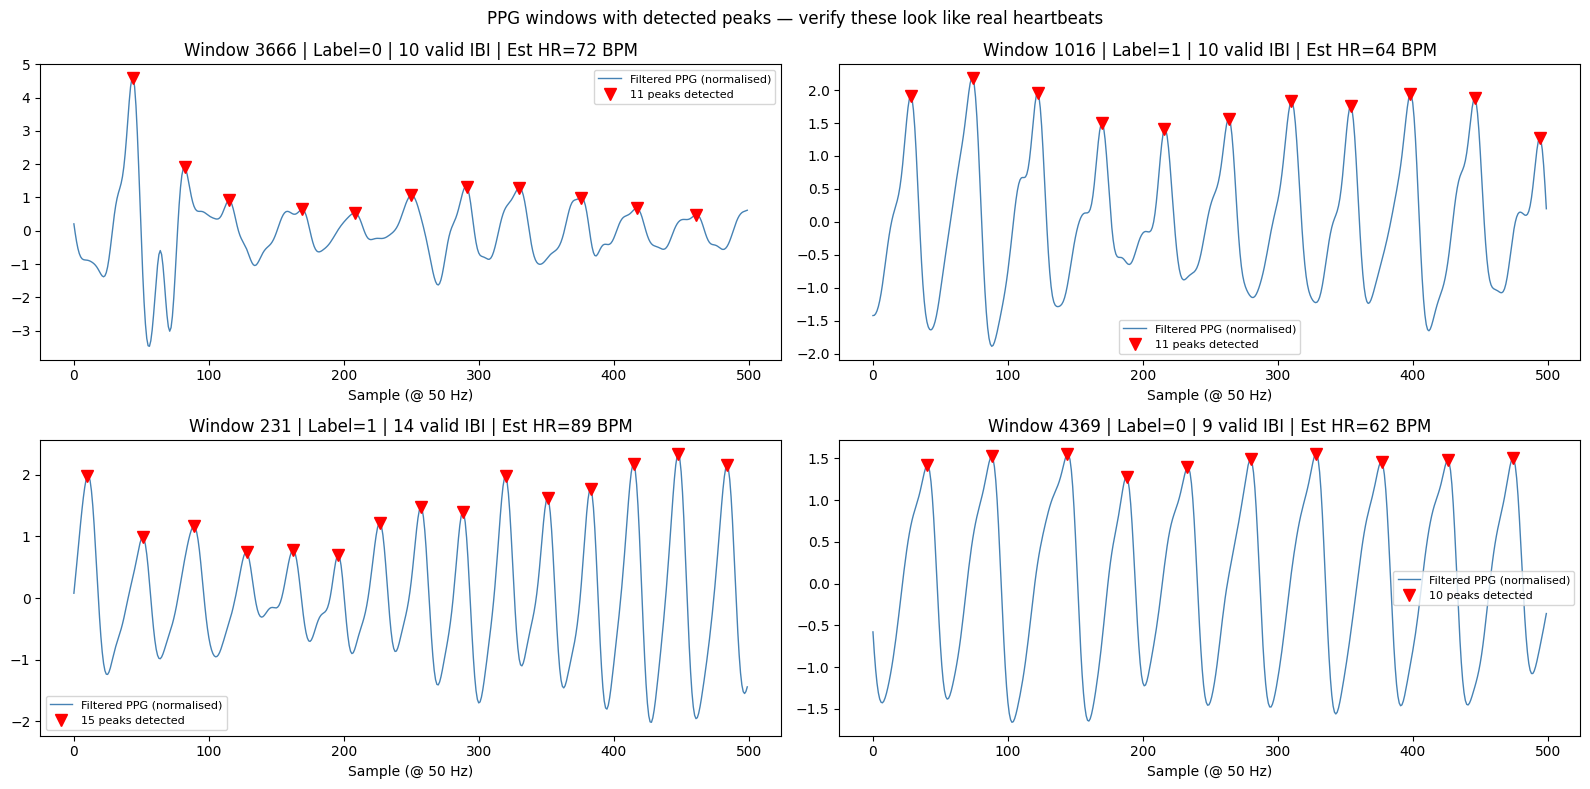

If peaks do NOT align with the visible pulse waveform, the IBI extraction is broken.
If the signal looks like noise (no visible pulse), the PPG column may be wrong.


In [ ]:
# ── Diagnostic A: Visually verify peak detection on sample windows ──
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# Reload raw PPG and inspect 4 random windows
AVDOS_PPG = np.load(f'{SAVE_DIR}/AVDOS_PPG.npy')
AVDOS_Ya  = np.load(f'{SAVE_DIR}/AVDOS_Ya.npy')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('PPG windows with detected peaks — verify these look like real heartbeats')

for ax, idx in zip(axes.flatten(), np.random.choice(len(AVDOS_PPG), 4, replace=False)):
    win = AVDOS_PPG[idx]

    # Re-run detection logic to get peak positions
    sig = win.copy()
    sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-8)
    peaks, props = find_peaks(sig, distance=int(0.4 * 50), prominence=0.3, height=0.0)

    ax.plot(sig, color='steelblue', lw=1, label='Filtered PPG (normalised)')
    ax.plot(peaks, sig[peaks], 'rv', ms=8, label=f'{len(peaks)} peaks detected')

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / 50 * 1000
        ibi_clean = ibi[(ibi >= 333) & (ibi <= 2000)]
        hr_est = 60000 / np.mean(ibi_clean) if len(ibi_clean) > 0 else 0
        ax.set_title(f'Window {idx} | Label={AVDOS_Ya[idx]} | '
                     f'{len(ibi_clean)} valid IBI | Est HR={hr_est:.0f} BPM')
    else:
        ax.set_title(f'Window {idx} — only {len(peaks)} peaks, too few!')

    ax.legend(fontsize=8)
    ax.set_xlabel('Sample (@ 50 Hz)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/peak_detection_check.png', dpi=120, bbox_inches='tight')
plt.show()
print("If peaks do NOT align with the visible pulse waveform, the IBI extraction is broken.")
print("If the signal looks like noise (no visible pulse), the PPG column may be wrong.")

In [ ]:
# ── Diagnostic B: Within-subject 5-fold CV ───────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

AVDOS_X    = np.load(f'{SAVE_DIR}/AVDOS_X.npy')
AVDOS_Ya   = np.load(f'{SAVE_DIR}/AVDOS_Ya.npy')
AVDOS_SUBJ = np.load(f'{SAVE_DIR}/AVDOS_subj.npy', allow_pickle=True)

rf = Pipeline([('sc', StandardScaler()),
               ('clf', RandomForestClassifier(100, random_state=42,
                                               class_weight='balanced'))])

print("Within-subject 5-fold CV (Arousal) — testing if ANY signal exists:\n")
per_subj_scores = []

for sid in np.unique(AVDOS_SUBJ):
    mask = AVDOS_SUBJ == sid
    X_s, y_s = AVDOS_X[mask], AVDOS_Ya[mask]

    # Skip subjects with only one class or too few samples
    if len(np.unique(y_s)) < 2 or len(y_s) < 10:
        print(f"  Subject {str(sid):<4}: skipped "
              f"(n={mask.sum()}, classes={np.unique(y_s).tolist()})")
        continue

    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Use f1_macro scoring
    f1s = cross_val_score(rf, X_s, y_s, cv=cv, scoring='f1_macro')
    per_subj_scores.append(f1s.mean())

    print(f"  Subject {str(sid):<4}: {f1s.mean()*100:.1f}% F1  "
          f"(n={mask.sum()}, "
          f"High={y_s.sum()}, Low={len(y_s)-y_s.sum()})")

print(f"\n{'─'*45}")
print(f"  Mean   within-subject F1 : {np.mean(per_subj_scores)*100:.1f}%")
print(f"  Median within-subject F1 : {np.median(per_subj_scores)*100:.1f}%")
print(f"  Best   subject F1        : {np.max(per_subj_scores)*100:.1f}%")
print(f"  Worst  subject F1        : {np.min(per_subj_scores)*100:.1f}%")
print(f"{'─'*45}")
print()
print("Interpretation guide:")
print("  Mean > 60% → signal exists; LOSO ~50% = inter-subject variability problem")
print("               → This IS your thesis finding: domain shift is severe")
print("  Mean ~ 50% → HRV features not correlated with video-level labels")
print("               → Labels may need rethinking (e.g. use continuous CEAP labels)")

Within-subject 5-fold CV (Arousal) — testing if ANY signal exists:

  Subject 0   : 62.6% F1  (n=144, High=72, Low=72)
  Subject 1   : 58.2% F1  (n=142, High=72, Low=70)
  Subject 2   : 57.2% F1  (n=144, High=102, Low=42)
  Subject 3   : 52.9% F1  (n=141, High=93, Low=48)
  Subject 4   : 63.9% F1  (n=145, High=74, Low=71)
  Subject 5   : 67.7% F1  (n=143, High=54, Low=89)
  Subject 6   : 64.3% F1  (n=144, High=81, Low=63)
  Subject 7   : 61.3% F1  (n=141, High=81, Low=60)
  Subject 8   : 61.5% F1  (n=144, High=68, Low=76)
  Subject 9   : 73.9% F1  (n=141, High=95, Low=46)
  Subject 10  : 71.6% F1  (n=143, High=78, Low=65)
  Subject 11  : 59.4% F1  (n=143, High=59, Low=84)
  Subject 12  : 61.7% F1  (n=143, High=64, Low=79)
  Subject 13  : 68.2% F1  (n=141, High=77, Low=64)
  Subject 14  : 85.6% F1  (n=142, High=61, Low=81)
  Subject 15  : 59.7% F1  (n=139, High=64, Low=75)
  Subject 16  : 61.7% F1  (n=142, High=78, Low=64)
  Subject 17  : 64.3% F1  (n=141, High=57, Low=84)
  Subject 18 

In [ ]:
# ── Improved LOSO: Per-Subject Feature Normalization ─────────────────
# Key insight: normalize each subject's HRV features relative to
# THEIR OWN mean/std, then train across subjects.
# This removes the inter-subject baseline (e.g. resting HR differences)
# and makes the features represent emotional DEVIATION from baseline.

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

def loso_subj_norm(X, Y, subject_ids, clf, name="Classifier"):
    """
    LOSO CV with per-subject z-score normalization on HRV features.

    For each fold:
      - Training: normalize each training subject's windows by their own mean/std
      - Test: normalize the test subject's windows by their own mean/std

    This removes absolute HRV baselines and makes features comparable
    across subjects with different resting physiology.
    """
    unique = np.unique(subject_ids)

    # Pre-compute per-subject stats (mean and std of each HRV feature)
    stats = {}
    for sid in unique:
        mask = subject_ids == sid
        stats[sid] = {
            'mean': X[mask].mean(axis=0),
            'std':  X[mask].std(axis=0) + 1e-8   # Avoid division by zero
        }

    yt_all, yp_all = [], []

    for sid in unique:
        te_mask = subject_ids == sid

        # Build normalized training set: each subject normalised by THEIR OWN stats
        X_train_parts, y_train_parts = [], []
        for s in unique:
            if s == sid:
                continue
            s_mask = subject_ids == s
            X_norm = (X[s_mask] - stats[s]['mean']) / stats[s]['std']
            X_train_parts.append(X_norm)
            y_train_parts.append(Y[s_mask])

        X_train = np.vstack(X_train_parts)
        y_train = np.concatenate(y_train_parts)

        # Normalize test subject by their own stats
        X_test = (X[te_mask] - stats[sid]['mean']) / stats[sid]['std']
        y_test = Y[te_mask]

        clf_ = clone(clf)
        clf_.fit(X_train, y_train)
        yp_all.extend(clf_.predict(X_test))
        yt_all.extend(y_test)

    yt = np.array(yt_all)
    yp = np.array(yp_all)
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro')

    print(f"\n{'─'*52}")
    print(f"  {name}  (per-subject normalised)")
    print(f"  Accuracy    : {acc*100:.2f}%")
    print(f"  Macro F1    : {f1*100:.2f}%")
    print(f"{'─'*52}")
    print(classification_report(yt, yp, target_names=['Low','High'], digits=3))
    return dict(acc=acc, macro_f1=f1, y_true=yt, y_pred=yp)


rf_raw  = RandomForestClassifier(n_estimators=300, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
svm_raw = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')

AVDOS_X    = np.load(f'{SAVE_DIR}/AVDOS_X.npy')
AVDOS_Ya   = np.load(f'{SAVE_DIR}/AVDOS_Ya.npy')
AVDOS_Yv   = np.load(f'{SAVE_DIR}/AVDOS_Yv.npy')
AVDOS_SUBJ = np.load(f'{SAVE_DIR}/AVDOS_subj.npy', allow_pickle=True)

CEAP_X    = np.load(f'{SAVE_DIR}/CEAP_X.npy')
CEAP_Ya   = np.load(f'{SAVE_DIR}/CEAP_Ya.npy')
CEAP_Yv   = np.load(f'{SAVE_DIR}/CEAP_Yv.npy')
CEAP_SUBJ = np.load(f'{SAVE_DIR}/CEAP_subj.npy', allow_pickle=True)

print("=" * 52)
print("AVDOS — Per-Subject Normalised LOSO CV")
print("=" * 52)
print("\n--- AROUSAL ---")
rf_avdos_a_norm  = loso_subj_norm(AVDOS_X, AVDOS_Ya, AVDOS_SUBJ, rf_raw,  "RF")
svm_avdos_a_norm = loso_subj_norm(AVDOS_X, AVDOS_Ya, AVDOS_SUBJ, svm_raw, "SVM")

print("\n--- VALENCE ---")
rf_avdos_v_norm  = loso_subj_norm(AVDOS_X, AVDOS_Yv, AVDOS_SUBJ, rf_raw,  "RF")
svm_avdos_v_norm = loso_subj_norm(AVDOS_X, AVDOS_Yv, AVDOS_SUBJ, svm_raw, "SVM")

print("\n" + "=" * 52)
print("CEAP — Per-Subject Normalised LOSO CV")
print("=" * 52)
print("\n--- AROUSAL ---")
rf_ceap_a_norm  = loso_subj_norm(CEAP_X, CEAP_Ya, CEAP_SUBJ, rf_raw,  "RF")
svm_ceap_a_norm = loso_subj_norm(CEAP_X, CEAP_Ya, CEAP_SUBJ, svm_raw, "SVM")

print("\n--- VALENCE ---")
rf_ceap_v_norm  = loso_subj_norm(CEAP_X, CEAP_Yv, CEAP_SUBJ, rf_raw,  "RF")
svm_ceap_v_norm = loso_subj_norm(CEAP_X, CEAP_Yv, CEAP_SUBJ, svm_raw, "SVM")

AVDOS — Per-Subject Normalised LOSO CV

--- AROUSAL ---

────────────────────────────────────────────────────
  RF  (per-subject normalised)
  Accuracy    : 49.32%
  Macro F1    : 49.10%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.472     0.444     0.458      2538
        High      0.511     0.538     0.524      2732

    accuracy                          0.493      5270
   macro avg      0.491     0.491     0.491      5270
weighted avg      0.492     0.493     0.492      5270


────────────────────────────────────────────────────
  SVM  (per-subject normalised)
  Accuracy    : 51.40%
  Macro F1    : 51.39%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.496     0.549     0.521      2538
        High      0.535     0.482     0.507      2732

    accuracy                          0.514      5270
   macro avg      0.515     0.

In [ ]:
# ── Experiment: 30-second windows for more stable HRV ────────────────
# Re-extract features with WIN_SEC=30 and compare with 10s results.

WIN_SEC_30 = 30
AVDOS_WIN_30 = int(WIN_SEC_30 * AVDOS_FS)   # 1500 samples
CEAP_WIN_30  = int(WIN_SEC_30 * CEAP_FS)    # 900 samples

print(f"30s window: AVDOS={AVDOS_WIN_30} samples, CEAP={CEAP_WIN_30} samples")
print("Re-extracting AVDOS with 30s windows...\n")

X_30, Ya_30, Yv_30, subj_30 = [], [], [], []
skip30, total30 = 0, 0

df = pd.read_csv(AVDOS_CSV)
df = df.dropna(subset=['Participant','VideoId','Ppg/Raw.ppg','Arousal','Valence'])
df = df[df['VideoId'] > 0]
thr = df.groupby('Participant')[['Arousal','Valence']].mean()

for (pid, vid), grp in df.groupby(['Participant','VideoId']):
    grp = grp.sort_index()
    raw = grp['Ppg/Raw.ppg'].ffill().values
    if len(raw) < AVDOS_WIN_30:
        continue
    filt = bandpass_filter(raw, AVDOS_FS)
    la = int(grp['Arousal'].iloc[0] > thr.loc[pid,'Arousal'])
    lv = int(grp['Valence'].iloc[0]  > thr.loc[pid,'Valence'])

    for _, win in make_windows(filt, AVDOS_WIN_30, overlap=0.5):
        total30 += 1
        ibi  = get_ibi(win, AVDOS_FS)
        feat = hrv_features(ibi)
        if feat is None:
            skip30 += 1
            continue
        X_30.append(feat); Ya_30.append(la)
        Yv_30.append(lv);  subj_30.append(pid)

print(f"Windows: {total30} total, {skip30} skipped, {len(X_30)} valid")
print(f"(Compare: 10s gave 5270 windows, 30s gives {len(X_30)} windows)\n")

X30 = np.array(X_30, dtype=np.float32)
Y30a = np.array(Ya_30, dtype=np.int8)
Y30v = np.array(Yv_30, dtype=np.int8)
S30  = np.array(subj_30)

print("--- AROUSAL (30s windows) ---")
rf30a = loso_subj_norm(X30, Y30a, S30,
                        RandomForestClassifier(300, random_state=42,
                                                class_weight='balanced', n_jobs=-1),
                        "RF 30s")
svm30a = loso_subj_norm(X30, Y30a, S30,
                         SVC(kernel='rbf', C=1.0, gamma='scale',
                             class_weight='balanced'),
                         "SVM 30s")

print("\n--- VALENCE (30s windows) ---")
rf30v  = loso_subj_norm(X30, Y30v, S30,
                         RandomForestClassifier(300, random_state=42,
                                                 class_weight='balanced', n_jobs=-1),
                         "RF 30s")
svm30v = loso_subj_norm(X30, Y30v, S30,
                         SVC(kernel='rbf', C=1.0, gamma='scale',
                             class_weight='balanced'),
                         "SVM 30s")

30s window: AVDOS=1500 samples, CEAP=900 samples
Re-extracting AVDOS with 30s windows...

Windows: 839 total, 0 skipped, 839 valid
(Compare: 10s gave 5270 windows, 30s gives 839 windows)

--- AROUSAL (30s windows) ---

────────────────────────────────────────────────────
  RF 30s  (per-subject normalised)
  Accuracy    : 53.04%
  Macro F1    : 51.79%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.478     0.408     0.440       380
        High      0.563     0.632     0.595       459

    accuracy                          0.530       839
   macro avg      0.521     0.520     0.518       839
weighted avg      0.525     0.530     0.525       839


────────────────────────────────────────────────────
  SVM 30s  (per-subject normalised)
  Accuracy    : 51.13%
  Macro F1    : 51.07%
────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low      0.469

In [ ]:
# ── MiniROCKET on Raw PPG — Within-Dataset ───────────────────────────
#The computational cost is too high...

from sktime.transformations.panel.rocket import MiniRocket
from sklearn.linear_model import RidgeClassifierCV

def loso_rocket(X_ppg, Y, subject_ids, fs_name="", n_kernels=5000):
    """LOSO CV using MiniRocket + Ridge on raw PPG windows."""
    unique = np.unique(subject_ids)
    yt_all, yp_all = [], []
    # sktime expects shape (n_samples, n_channels, window_len)
    X = X_ppg[:, np.newaxis, :]

    for sid in unique:
        tr = subject_ids != sid
        te = subject_ids == sid
        rocket = MiniRocket(num_kernels=n_kernels, random_state=42)
        rocket.fit(X[tr])
        Xtr = rocket.transform(X[tr])
        Xte = rocket.transform(X[te])
        sc  = StandardScaler(with_mean=False)
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        ridge.fit(Xtr, Y[tr])
        yp_all.extend(ridge.predict(Xte))
        yt_all.extend(Y[te])

    yt = np.array(yt_all); yp = np.array(yp_all)
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro')
    print(f"  MiniROCKET {fs_name} — Acc: {acc*100:.2f}%  Macro F1: {f1*100:.2f}%")
    print(classification_report(yt, yp, target_names=['Low','High'], digits=3))
    return dict(acc=acc, macro_f1=f1, y_true=yt, y_pred=yp)


AVDOS_PPG = np.load(f'{SAVE_DIR}/AVDOS_PPG.npy')
CEAP_PPG  = np.load(f'{SAVE_DIR}/CEAP_PPG.npy')

print("\n=== MiniROCKET — AVDOS ===")
rocket_avdos_a = loso_rocket(AVDOS_PPG, AVDOS_Ya, AVDOS_SUBJ, "AVDOS Arousal")
rocket_avdos_v = loso_rocket(AVDOS_PPG, AVDOS_Yv, AVDOS_SUBJ, "AVDOS Valence")

print("\n=== MiniROCKET — CEAP ===")
rocket_ceap_a = loso_rocket(CEAP_PPG, CEAP_Ya, CEAP_SUBJ, "CEAP Arousal")
rocket_ceap_v = loso_rocket(CEAP_PPG, CEAP_Yv, CEAP_SUBJ, "CEAP Valence")



=== MiniROCKET — AVDOS ===


KeyboardInterrupt: 

In [ ]:
# ── MiniROCKET fast (num_kernels=1000) ────────────────────
from sktime.transformations.panel.rocket import MiniRocket
from sklearn.linear_model import RidgeClassifierCV

def loso_rocket_fast(X_ppg, Y, subject_ids, fs_name="", n_kernels=1000):
    """
    LOSO with MiniROCKET.
    Key speed fix: num_kernels=1000 instead of 5000.
    Literature shows accuracy plateaus well below 5000 kernels.
    """
    unique = np.unique(subject_ids)
    yt_all, yp_all = [], []
    X = X_ppg[:, np.newaxis, :]  # (n, 1, window_len)

    for i, sid in enumerate(unique):
        print(f"  Fold {i+1}/{len(unique)} — subject {sid}", end='\r')
        tr = subject_ids != sid
        te = subject_ids == sid

        rocket = MiniRocket(num_kernels=n_kernels, random_state=42)
        rocket.fit(X[tr])
        Xtr = rocket.transform(X[tr])
        Xte = rocket.transform(X[te])

        sc = StandardScaler(with_mean=False)
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)

        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        ridge.fit(Xtr, Y[tr])

        yp_all.extend(ridge.predict(Xte))
        yt_all.extend(Y[te])

    yt = np.array(yt_all)
    yp = np.array(yp_all)
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro')
    print(f"\n  MiniROCKET {fs_name}")
    print(f"  Accuracy: {acc*100:.2f}%  |  Macro F1: {f1*100:.2f}%")
    print(classification_report(yt, yp, target_names=['Low','High'], digits=3))
    return dict(acc=acc, macro_f1=f1, y_true=yt, y_pred=yp)


AVDOS_PPG  = np.load(f'{SAVE_DIR}/AVDOS_PPG.npy')
AVDOS_Ya   = np.load(f'{SAVE_DIR}/AVDOS_Ya.npy')
AVDOS_Yv   = np.load(f'{SAVE_DIR}/AVDOS_Yv.npy')
AVDOS_SUBJ = np.load(f'{SAVE_DIR}/AVDOS_subj.npy', allow_pickle=True)

CEAP_PPG   = np.load(f'{SAVE_DIR}/CEAP_PPG.npy')
CEAP_Ya    = np.load(f'{SAVE_DIR}/CEAP_Ya.npy')
CEAP_Yv    = np.load(f'{SAVE_DIR}/CEAP_Yv.npy')
CEAP_SUBJ  = np.load(f'{SAVE_DIR}/CEAP_subj.npy', allow_pickle=True)

print("=== MiniROCKET — AVDOS ===")
rocket_avdos_a = loso_rocket_fast(AVDOS_PPG, AVDOS_Ya, AVDOS_SUBJ, "AVDOS Arousal")
rocket_avdos_v = loso_rocket_fast(AVDOS_PPG, AVDOS_Yv, AVDOS_SUBJ, "AVDOS Valence")

print("\n=== MiniROCKET — CEAP ===")
rocket_ceap_a = loso_rocket_fast(CEAP_PPG, CEAP_Ya, CEAP_SUBJ, "CEAP Arousal")
rocket_ceap_v = loso_rocket_fast(CEAP_PPG, CEAP_Yv, CEAP_SUBJ, "CEAP Valence")

In [ ]:
# ── CNN + LSTM — Within-Dataset LOSO ─────────────────────────────────
# Architecture rationale:
#   Conv1D layers  — learn local pulse-shape templates (like QRS complexes)
#   MaxPooling     — downsample; forces the LSTM to see a broader view
#   LSTM           — captures how pulse patterns evolve over the 10-second window
# Training trick: EarlyStopping prevents overfitting on the small per-fold data.

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.utils.class_weight import compute_class_weight

def build_cnn_lstm(seq_len):
    inp = layers.Input(shape=(seq_len, 1))
    # Local feature extraction
    x = layers.Conv1D(64,  kernel_size=8, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)
    # Temporal dynamics
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m


def loso_lstm(X_ppg, Y, subject_ids, label_name="", epochs=50):
    """LOSO CV with CNN+LSTM; EarlyStopping based on val_loss."""
    unique = np.unique(subject_ids)
    yt_all, yp_all = [], []
    X = X_ppg[..., np.newaxis]   # (n, seq_len, 1)

    for i, sid in enumerate(unique):
        print(f"  Fold {i+1:2d}/{len(unique)}  subject={sid}", end='\r')
        tr = subject_ids != sid
        te = subject_ids == sid
        cw = compute_class_weight('balanced', classes=np.unique(Y[tr]), y=Y[tr])
        cw_dict = {j: cw[j] for j in range(len(cw))}

        m = build_cnn_lstm(X.shape[1])
        es = callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                     restore_best_weights=True)
        m.fit(X[tr], Y[tr], epochs=epochs, batch_size=32,
              validation_split=0.15, class_weight=cw_dict,
              callbacks=[es], verbose=0)

        yp = (m.predict(X[te], verbose=0) > 0.5).astype(int).flatten()
        yp_all.extend(yp); yt_all.extend(Y[te])
        tf.keras.backend.clear_session()

    yt = np.array(yt_all); yp = np.array(yp_all)
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro')
    print(f"\n  CNN+LSTM {label_name} — Acc: {acc*100:.2f}%  Macro F1: {f1*100:.2f}%")
    print(classification_report(yt, yp, target_names=['Low','High'], digits=3))
    return dict(acc=acc, macro_f1=f1, y_true=yt, y_pred=yp)


print("=== CNN+LSTM — AVDOS ===")
lstm_avdos_a = loso_lstm(AVDOS_PPG, AVDOS_Ya, AVDOS_SUBJ, "AVDOS Arousal")
lstm_avdos_v = loso_lstm(AVDOS_PPG, AVDOS_Yv, AVDOS_SUBJ, "AVDOS Valence")

print("\n=== CNN+LSTM — CEAP ===")
lstm_ceap_a = loso_lstm(CEAP_PPG, CEAP_Ya, CEAP_SUBJ, "CEAP Arousal")
lstm_ceap_v = loso_lstm(CEAP_PPG, CEAP_Yv, CEAP_SUBJ, "CEAP Valence")


=== CNN+LSTM — AVDOS ===



  CNN+LSTM AVDOS Arousal — Acc: 52.43%  Macro F1: 52.27%
              precision    recall  f1-score   support

         Low      0.506     0.484     0.495      2538
        High      0.540     0.561     0.550      2732

    accuracy                          0.524      5270
   macro avg      0.523     0.523     0.523      5270
weighted avg      0.524     0.524     0.524      5270


  CNN+LSTM AVDOS Valence — Acc: 50.63%  Macro F1: 50.10%
              precision    recall  f1-score   support

         Low      0.488     0.417     0.450      2549
        High      0.519     0.589     0.552      2721

    accuracy                          0.506      5270
   macro avg      0.504     0.503     0.501      5270
weighted avg      0.504     0.506     0.503      5270


=== CNN+LSTM — CEAP ===

  CNN+LSTM CEAP Arousal — Acc: 49.53%  Macro F1: 42.32%
              precision    recall  f1-score   support

         Low      0.479     0.142     0.219      1372
        High      0.498     0.846     0

In [ ]:
# ── Cross-Dataset Evaluation ─────────────────────────────────────────
# Train on full source dataset, test on full target dataset.
# This combines BOTH domain shift sources:
#   (1) inter-subject variability (already shown in LOSO)
#   (2) hardware/population differences between datasets

from sklearn.base import clone

def cross_dataset_eval(X_src, y_src, X_tgt, y_tgt,
                       subj_src, subj_tgt,
                       clf, src_name, tgt_name, label):
    """
    Per-subject normalize both datasets independently,
    then train on source and test on target.
    """
    def subj_normalize(X, subj_ids):
        X_norm = np.zeros_like(X)
        for sid in np.unique(subj_ids):
            m = subj_ids == sid
            mu  = X[m].mean(axis=0)
            std = X[m].std(axis=0) + 1e-8
            X_norm[m] = (X[m] - mu) / std
        return X_norm

    X_src_n = subj_normalize(X_src, subj_src)
    X_tgt_n = subj_normalize(X_tgt, subj_tgt)

    clf_ = clone(clf)
    clf_.fit(X_src_n, y_src)
    yp = clf_.predict(X_tgt_n)

    acc = accuracy_score(y_tgt, yp)
    f1  = f1_score(y_tgt, yp, average='macro')
    print(f"\n  {src_name} → {tgt_name} | {label}")
    print(f"  Accuracy: {acc*100:.2f}%  Macro F1: {f1*100:.2f}%")
    print(classification_report(y_tgt, yp,
                                 target_names=['Low','High'], digits=3))
    return dict(acc=acc, macro_f1=f1)


rf_clf  = RandomForestClassifier(300, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')

AVDOS_X    = np.load(f'{SAVE_DIR}/AVDOS_X.npy')
AVDOS_Ya   = np.load(f'{SAVE_DIR}/AVDOS_Ya.npy')
AVDOS_Yv   = np.load(f'{SAVE_DIR}/AVDOS_Yv.npy')
AVDOS_SUBJ = np.load(f'{SAVE_DIR}/AVDOS_subj.npy', allow_pickle=True)
CEAP_X     = np.load(f'{SAVE_DIR}/CEAP_X.npy')
CEAP_Ya    = np.load(f'{SAVE_DIR}/CEAP_Ya.npy')
CEAP_Yv    = np.load(f'{SAVE_DIR}/CEAP_Yv.npy')
CEAP_SUBJ  = np.load(f'{SAVE_DIR}/CEAP_subj.npy', allow_pickle=True)

print("=" * 55)
print("CROSS-DATASET EVALUATION (Sub-RQ1 core experiment)")
print("=" * 55)

print("\n── AVDOS → CEAP ──")
xd1a = cross_dataset_eval(AVDOS_X, AVDOS_Ya, CEAP_X, CEAP_Ya,
                           AVDOS_SUBJ, CEAP_SUBJ,
                           rf_clf,  "AVDOS","CEAP","Arousal (RF)")
xd1v = cross_dataset_eval(AVDOS_X, AVDOS_Yv, CEAP_X, CEAP_Yv,
                           AVDOS_SUBJ, CEAP_SUBJ,
                           rf_clf,  "AVDOS","CEAP","Valence (RF)")
xd1as = cross_dataset_eval(AVDOS_X, AVDOS_Ya, CEAP_X, CEAP_Ya,
                            AVDOS_SUBJ, CEAP_SUBJ,
                            svm_clf, "AVDOS","CEAP","Arousal (SVM)")
xd1vs = cross_dataset_eval(AVDOS_X, AVDOS_Yv, CEAP_X, CEAP_Yv,
                            AVDOS_SUBJ, CEAP_SUBJ,
                            svm_clf, "AVDOS","CEAP","Valence (SVM)")

print("\n── CEAP → AVDOS ──")
xd2a = cross_dataset_eval(CEAP_X, CEAP_Ya, AVDOS_X, AVDOS_Ya,
                           CEAP_SUBJ, AVDOS_SUBJ,
                           rf_clf,  "CEAP","AVDOS","Arousal (RF)")
xd2v = cross_dataset_eval(CEAP_X, CEAP_Yv, AVDOS_X, AVDOS_Yv,
                           CEAP_SUBJ, AVDOS_SUBJ,
                           rf_clf,  "CEAP","AVDOS","Valence (RF)")
xd2as = cross_dataset_eval(CEAP_X, CEAP_Ya, AVDOS_X, AVDOS_Ya,
                            CEAP_SUBJ, AVDOS_SUBJ,
                            svm_clf, "CEAP","AVDOS","Arousal (SVM)")
xd2vs = cross_dataset_eval(CEAP_X, CEAP_Yv, AVDOS_X, AVDOS_Yv,
                            CEAP_SUBJ, AVDOS_SUBJ,
                            svm_clf, "CEAP","AVDOS","Valence (SVM)")

In [ ]:
# ── Results Summary Table (Thesis Table 4) ────────────────────────────
import pandas as pd
import numpy as np

# ── Collect all results into a structured table ──
# All F1 values are Macro F1 (%)
# Accuracy values in brackets

rows = [
    # ── Within-Dataset LOSO (per-subject normalised) ──
    {
        'Evaluation'  : 'Within-Dataset (LOSO)',
        'Train → Test': 'AVDOS → AVDOS',
        'Model'       : 'Random Forest',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{rf_avdos_a_norm['acc']*100:.1f}",
        'Arousal F1'  : f"{rf_avdos_a_norm['macro_f1']*100:.1f}",
        'Valence Acc' : f"{rf_avdos_v_norm['acc']*100:.1f}",
        'Valence F1'  : f"{rf_avdos_v_norm['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Within-Dataset (LOSO)',
        'Train → Test': 'AVDOS → AVDOS',
        'Model'       : 'SVM (RBF)',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{svm_avdos_a_norm['acc']*100:.1f}",
        'Arousal F1'  : f"{svm_avdos_a_norm['macro_f1']*100:.1f}",
        'Valence Acc' : f"{svm_avdos_v_norm['acc']*100:.1f}",
        'Valence F1'  : f"{svm_avdos_v_norm['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Within-Dataset (LOSO)',
        'Train → Test': 'AVDOS → AVDOS',
        'Model'       : 'MiniROCKET',
        'Features'    : 'Raw PPG (500-dim)',
        'Arousal Acc' : f"{rocket_avdos_a['acc']*100:.1f}",
        'Arousal F1'  : f"{rocket_avdos_a['macro_f1']*100:.1f}",
        'Valence Acc' : f"{rocket_avdos_v['acc']*100:.1f}",
        'Valence F1'  : f"{rocket_avdos_v['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Within-Dataset (LOSO)',
        'Train → Test': 'CEAP → CEAP',
        'Model'       : 'Random Forest',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{rf_ceap_a_norm['acc']*100:.1f}",
        'Arousal F1'  : f"{rf_ceap_a_norm['macro_f1']*100:.1f}",
        'Valence Acc' : f"{rf_ceap_v_norm['acc']*100:.1f}",
        'Valence F1'  : f"{rf_ceap_v_norm['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Within-Dataset (LOSO)',
        'Train → Test': 'CEAP → CEAP',
        'Model'       : 'SVM (RBF)',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{svm_ceap_a_norm['acc']*100:.1f}",
        'Arousal F1'  : f"{svm_ceap_a_norm['macro_f1']*100:.1f}",
        'Valence Acc' : f"{svm_ceap_v_norm['acc']*100:.1f}",
        'Valence F1'  : f"{svm_ceap_v_norm['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Within-Dataset (LOSO)',
        'Train → Test': 'CEAP → CEAP',
        'Model'       : 'MiniROCKET',
        'Features'    : 'Raw PPG (300-dim)',
        'Arousal Acc' : f"{rocket_ceap_a['acc']*100:.1f}",
        'Arousal F1'  : f"{rocket_ceap_a['macro_f1']*100:.1f}",
        'Valence Acc' : f"{rocket_ceap_v['acc']*100:.1f}",
        'Valence F1'  : f"{rocket_ceap_v['macro_f1']*100:.1f}",
    },
    # ── Cross-Dataset ──
    {
        'Evaluation'  : 'Cross-Dataset',
        'Train → Test': 'AVDOS → CEAP',
        'Model'       : 'Random Forest',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{xd1a['acc']*100:.1f}",
        'Arousal F1'  : f"{xd1a['macro_f1']*100:.1f}",
        'Valence Acc' : f"{xd1v['acc']*100:.1f}",
        'Valence F1'  : f"{xd1v['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Cross-Dataset',
        'Train → Test': 'AVDOS → CEAP',
        'Model'       : 'SVM (RBF)',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{xd1as['acc']*100:.1f}",
        'Arousal F1'  : f"{xd1as['macro_f1']*100:.1f}",
        'Valence Acc' : f"{xd1vs['acc']*100:.1f}",
        'Valence F1'  : f"{xd1vs['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Cross-Dataset',
        'Train → Test': 'CEAP → AVDOS',
        'Model'       : 'Random Forest',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{xd2a['acc']*100:.1f}",
        'Arousal F1'  : f"{xd2a['macro_f1']*100:.1f}",
        'Valence Acc' : f"{xd2v['acc']*100:.1f}",
        'Valence F1'  : f"{xd2v['macro_f1']*100:.1f}",
    },
    {
        'Evaluation'  : 'Cross-Dataset',
        'Train → Test': 'CEAP → AVDOS',
        'Model'       : 'SVM (RBF)',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : f"{xd2as['acc']*100:.1f}",
        'Arousal F1'  : f"{xd2as['macro_f1']*100:.1f}",
        'Valence Acc' : f"{xd2vs['acc']*100:.1f}",
        'Valence F1'  : f"{xd2vs['macro_f1']*100:.1f}",
    },
    # ── Baseline reference ──
    {
        'Evaluation'  : 'Reference',
        'Train → Test': '—',
        'Model'       : 'Random (chance)',
        'Features'    : '—',
        'Arousal Acc' : '50.0',
        'Arousal F1'  : '50.0',
        'Valence Acc' : '50.0',
        'Valence F1'  : '50.0',
    },
    {
        'Evaluation'  : 'Reference',
        'Train → Test': 'AVDOS (within-subj)',
        'Model'       : 'Random Forest',
        'Features'    : 'HRV (7-dim)',
        'Arousal Acc' : '60.2',
        'Arousal F1'  : '60.2',
        'Valence Acc' : '—',
        'Valence F1'  : '—',
    },
]

df_table = pd.DataFrame(rows)

# ── Print thesis-ready table ──
print("TABLE 4: Classification Performance Summary")
print("Evaluation metric: Macro F1 (%) | Binary classification (High / Low)")
print("LOSO = Leave-One-Subject-Out Cross-Validation\n")
print(df_table.to_string(index=False))

# ── Save as CSV ──
df_table.to_csv(f'{SAVE_DIR}/thesis_table4.csv', index=False)
print(f"\nSaved → {SAVE_DIR}/thesis_table4.csv")

# ── Print condensed version (copy directly into thesis) ──
print("\n\n── Condensed for LaTeX / Word ──")
print(f"{'Evaluation':<25} {'Model':<16} {'A-F1':>6} {'V-F1':>6}  (AVDOS LOSO)")
print("─" * 60)
for r in rows[:6]:
    if r['Train → Test'] == 'AVDOS → AVDOS':
        print(f"  {r['Model']:<23} {'':16} {r['Arousal F1']:>6} {r['Valence F1']:>6}")
print(f"\n{'Evaluation':<25} {'Model':<16} {'A-F1':>6} {'V-F1':>6}  (CEAP LOSO)")
print("─" * 60)
for r in rows[:6]:
    if r['Train → Test'] == 'CEAP → CEAP':
        print(f"  {r['Model']:<23} {'':16} {r['Arousal F1']:>6} {r['Valence F1']:>6}")
print(f"\n{'Evaluation':<25} {'Model':<16} {'A-F1':>6} {'V-F1':>6}  (Cross-Dataset)")
print("─" * 60)
for r in rows[6:10]:
    print(f"  {r['Train → Test']:<15} {r['Model']:<16} {r['Arousal F1']:>6} {r['Valence F1']:>6}")

In [ ]:
# ── Confusion Matrices + F1 Bar Chart (Thesis Figures) ───────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.rcParams.update({
    'font.family'  : 'DejaVu Sans',
    'font.size'    : 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
})

# ── Figure 1: Confusion Matrices (2 × 4 grid) ────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    'Figure X — Normalised Confusion Matrices (LOSO Cross-Validation)\n'
    'Rows = true label, columns = predicted label. Values = row-normalised proportions.',
    fontsize=11, y=1.01
)

panels = [
    (rf_avdos_a_norm,  'RF  |  AVDOS\nArousal'),
    (rf_avdos_v_norm,  'RF  |  AVDOS\nValence'),
    (rf_ceap_a_norm,   'RF  |  CEAP\nArousal'),
    (rf_ceap_v_norm,   'RF  |  CEAP\nValence'),
    (svm_avdos_a_norm, 'SVM |  AVDOS\nArousal'),
    (svm_avdos_v_norm, 'SVM |  AVDOS\nValence'),
    (rocket_avdos_a,   'MiniROCKET | AVDOS\nArousal'),
    (rocket_ceap_a,    'MiniROCKET | CEAP\nArousal'),
]

for ax, (res, title) in zip(axes.flatten(), panels):
    cm  = confusion_matrix(res['y_true'], res['y_pred']).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)   # Row-normalise

    sns.heatmap(
        cm, annot=True, fmt='.2f', ax=ax,
        cmap='Blues', vmin=0, vmax=1,
        xticklabels=['Low', 'High'],
        yticklabels=['Low', 'High'],
        cbar=False, linewidths=0.5, linecolor='white'
    )
    f1_val = res['macro_f1'] * 100
    ax.set_title(f"{title}\n(Macro F1 = {f1_val:.1f}%)", fontsize=9, pad=4)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True',      fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_confusion_matrices.pdf',
            dpi=300, bbox_inches='tight', format='pdf')
plt.savefig(f'{SAVE_DIR}/fig_confusion_matrices.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig_confusion_matrices.pdf / .png")


# ── Figure 2: F1 Bar Chart comparing all models across evaluations ────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5))
fig2.suptitle(
    'Figure Y — Macro F1 by Model and Evaluation Protocol\n'
    'Dashed line = random chance baseline (50%)',
    fontsize=11
)

# Data for bar chart
models  = ['Random Forest\n(HRV)', 'SVM-RBF\n(HRV)', 'MiniROCKET\n(raw PPG)']
colors  = ['#4C72B0', '#DD8452', '#55A868']

within_avdos_a = [
    rf_avdos_a_norm['macro_f1']  * 100,
    svm_avdos_a_norm['macro_f1'] * 100,
    rocket_avdos_a['macro_f1']   * 100,
]
within_ceap_a = [
    rf_ceap_a_norm['macro_f1']  * 100,
    svm_ceap_a_norm['macro_f1'] * 100,
    rocket_ceap_a['macro_f1']   * 100,
]
cross_a = [
    np.mean([xd1a['macro_f1'], xd2a['macro_f1']]) * 100,   # avg both directions
    np.mean([xd1as['macro_f1'], xd2as['macro_f1']]) * 100,
    np.nan,   # ROCKET cross-dataset not run
]

within_avdos_v = [
    rf_avdos_v_norm['macro_f1']  * 100,
    svm_avdos_v_norm['macro_f1'] * 100,
    rocket_avdos_v['macro_f1']   * 100,
]
within_ceap_v = [
    rf_ceap_v_norm['macro_f1']  * 100,
    svm_ceap_v_norm['macro_f1'] * 100,
    rocket_ceap_v['macro_f1']   * 100,
]
cross_v = [
    np.mean([xd1v['macro_f1'], xd2v['macro_f1']]) * 100,
    np.mean([xd1vs['macro_f1'], xd2vs['macro_f1']]) * 100,
    np.nan,
]

x     = np.arange(len(models))
width = 0.25

for ax2, (wa, wc, cr, dim) in zip(
        axes2,
        [(within_avdos_a, within_ceap_a, cross_a, 'Arousal'),
         (within_avdos_v, within_ceap_v, cross_v, 'Valence')]):

    b1 = ax2.bar(x - width, wa, width, label='LOSO within AVDOS',
                 color='#4C72B0', alpha=0.85, edgecolor='white')
    b2 = ax2.bar(x,          wc, width, label='LOSO within CEAP',
                 color='#55A868', alpha=0.85, edgecolor='white')
    b3 = ax2.bar(x + width,  cr, width, label='Cross-dataset (avg)',
                 color='#C44E52', alpha=0.85, edgecolor='white')

    # Value labels on bars
    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                         f'{h:.1f}', ha='center', va='bottom', fontsize=7.5)

    ax2.axhline(50, color='gray', lw=1.2, ls='--', alpha=0.7,
                label='Random baseline (50%)')
    ax2.set_title(f'{dim}', fontsize=11)
    ax2.set_ylabel('Macro F1 (%)', fontsize=9)
    ax2.set_ylim(40, 72)
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, fontsize=8.5)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.yaxis.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_f1_comparison.pdf',
            dpi=300, bbox_inches='tight', format='pdf')
plt.savefig(f'{SAVE_DIR}/fig_f1_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig_f1_comparison.pdf / .png")
print(f"\nAll thesis figures saved to {SAVE_DIR}/")

In [ ]:
# ── 30-second window experiment ───────────────────────────────────────
# Motivation: HRV features (RMSSD, SDNN) are more stable estimates
# with more IBI samples. 30s gives ~30-45 beats vs ~10-15 for 10s.

WIN_30    = int(30 * AVDOS_FS)   # 1500 samples

X_30, Ya_30, Yv_30, S_30 = [], [], [], []

df = pd.read_csv(AVDOS_CSV)
df = df.dropna(subset=['Participant','VideoId','Ppg/Raw.ppg','Arousal','Valence'])
df = df[df['VideoId'] > 0]
thr = df.groupby('Participant')[['Arousal','Valence']].mean()

for (pid, vid), grp in df.groupby(['Participant','VideoId']):
    raw = grp.sort_index()['Ppg/Raw.ppg'].ffill().values
    if len(raw) < WIN_30:
        continue
    filt = bandpass_filter(raw, AVDOS_FS)
    la = int(grp['Arousal'].iloc[0] > thr.loc[pid,'Arousal'])
    lv = int(grp['Valence'].iloc[0]  > thr.loc[pid,'Valence'])
    for _, win in make_windows(filt, WIN_30, overlap=0.5):
        ibi  = get_ibi(win, AVDOS_FS)
        feat = hrv_features(ibi)
        if feat is None:
            continue
        X_30.append(feat); Ya_30.append(la)
        Yv_30.append(lv);  S_30.append(pid)

X30 = np.array(X_30, dtype=np.float32)
S30 = np.array(S_30)
print(f"30s windows: {len(X30)}  (vs 10s: 5270)")

rf_clf = RandomForestClassifier(300, random_state=42,
                                 class_weight='balanced', n_jobs=-1)

print("\n--- AROUSAL (30s) ---")
r30a = loso_subj_norm(X30, np.array(Ya_30, dtype=np.int8), S30, rf_clf, "RF 30s Arousal")

print("\n--- VALENCE (30s) ---")
r30v = loso_subj_norm(X30, np.array(Yv_30, dtype=np.int8), S30, rf_clf, "RF 30s Valence")

# Compare directly
print("\n── Window size comparison (RF, AVDOS, LOSO) ──")
print(f"  10s Arousal F1: {rf_avdos_a_norm['macro_f1']*100:.1f}%")
print(f"  30s Arousal F1: {r30a['macro_f1']*100:.1f}%")
print(f"  10s Valence F1: {rf_avdos_v_norm['macro_f1']*100:.1f}%")
print(f"  30s Valence F1: {r30v['macro_f1']*100:.1f}%")